# Lattice-encrypted OFDM Simulation using Modular Library
This notebook imports the modular functions from `simulation_library` and executes the full simulation pipeline in a single cell, outputting all requested visualizations and metrics.

In [6]:
%load_ext autoreload
%autoreload 2

# 1. Import libraries
import os
import sys
import numpy as np
import torch
import matplotlib.pyplot as plt
import sionna
import sionna.phy

# IPython magic function for inline plots
%matplotlib inline

# Import from our modular library
from lattice import LatticeBasedEncryptor, qam16_lattice_to_normalized, qam16_slicer_lattice
from metrics import hadamard_ratio, hadamard_quality, matrix_condition_number, random_unimodular_matrix, generate_lattice_bases
from ber import bit_error_rate, llr_to_bits, nearest_neighbor_qam_demapper, db_to_linear_amplitude, receiver_amplifier
from plots import plot_constellation, plot_rx_only, plot_signal_snapshot, plot_zoomed_signal, plot_noisy_time_domain

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## End-to-End Simulation & Visualizations
Run the cell below to execute the full chain (Data generation -> Mapping -> Encryption -> OFDM modulation -> Attenuating AWGN Channel -> Receiver Amplifier -> Equalized Demodulation -> Linear/Babai decryption -> Hard Demapping) and plot the results.

R quality: good  HR(R)=8.7557e-01  rho_R=0.2754
B quality: NOT below badTh  HR(B)=7.8138e-01  rho_B=1.1287
Usable error scale: 4.4299e-01 < sigma < 1.8153e+00
Private basis R shape: (350, 350) | Public basis B shape: (350, 350)
sigma = 1.6337e+00  (window 4.430e-01 .. 1.815e+00)

--- TRANSMITTED SIGNAL SNAPSHOT AND ZOOM ---


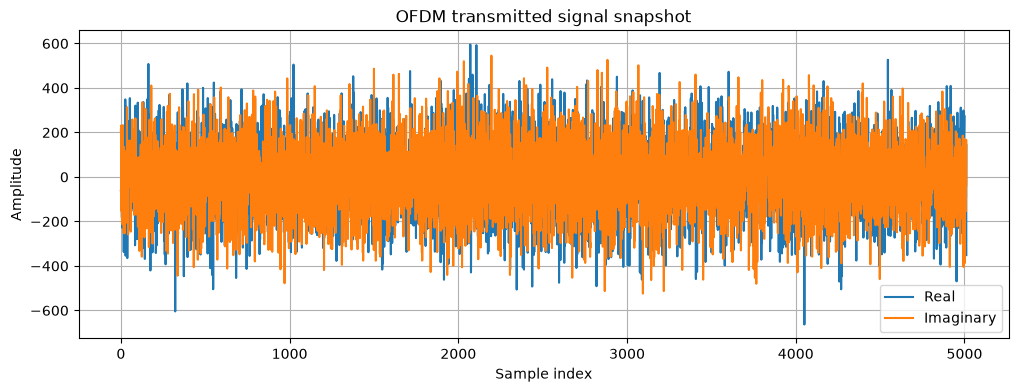

t0: symbol = -62.4398+206.2247j, I = -62.4398, Q = 206.2247
t1: symbol = -70.9535+230.7932j, I = -70.9535, Q = 230.7932
t2: symbol = -42.5025-153.1264j, I = -42.5025, Q = -153.1264
t3: symbol = 52.1152+94.0333j, I = 52.1152, Q = 94.0333


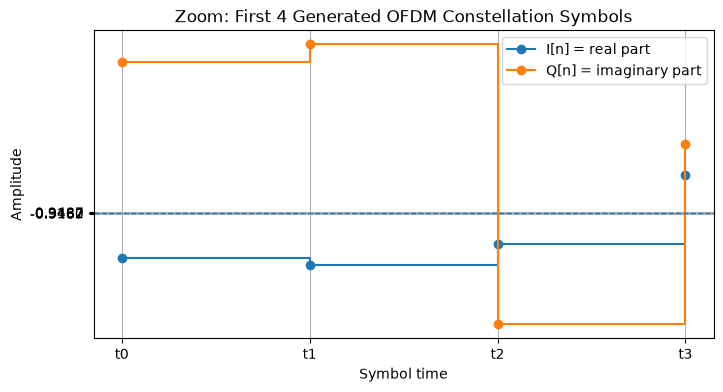

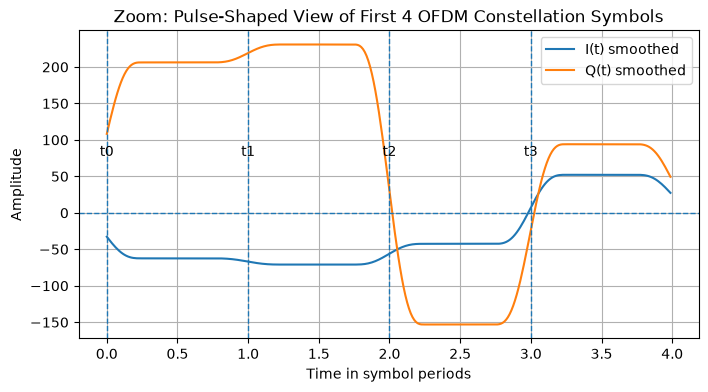


--- NOISY TIME DOMAIN OF OFDM SAMPLES ---


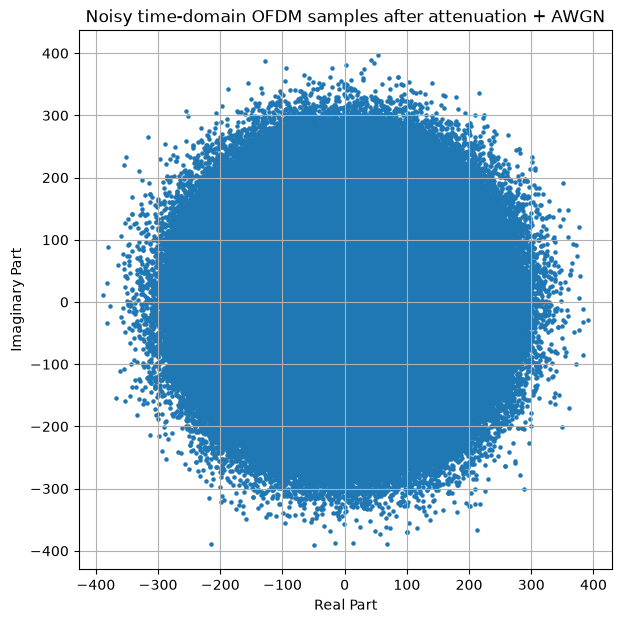


--- ENCRYPTED RECEIVED CONSTELLATION ---


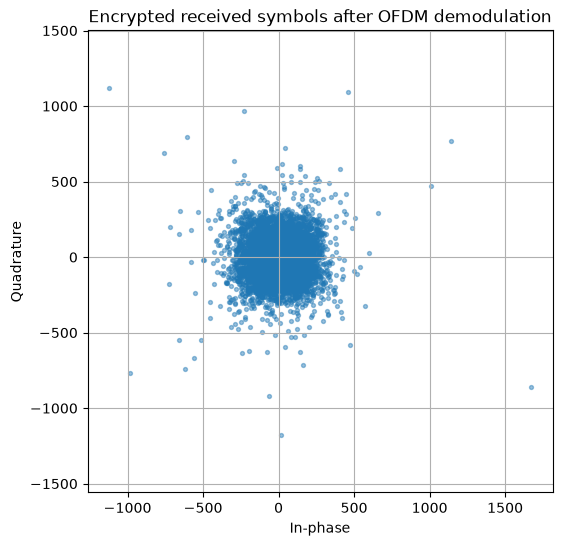

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.



--- DECRYPTED RECEIVED CONSTELLATION PLOTS ---


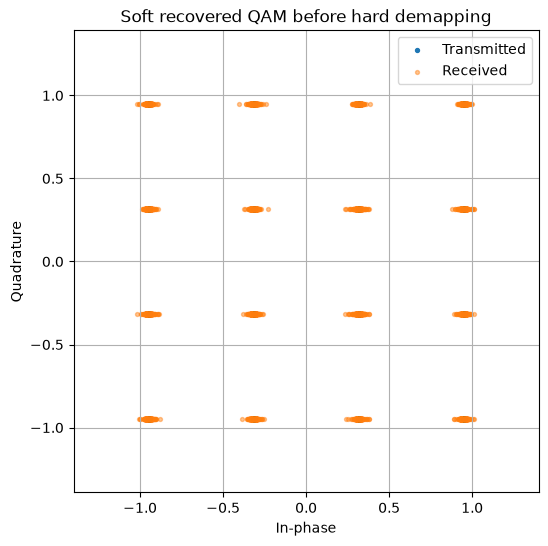

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


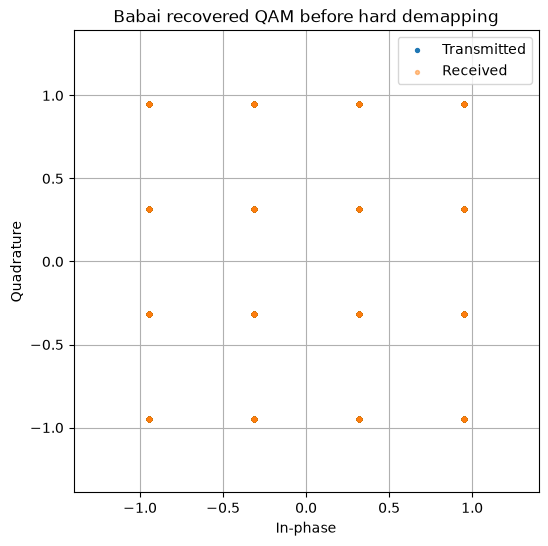


--- COMPUTATIONS AND RESULTS ---
Soft recovery symbol error: 1.285291e-02
Babai recovery symbol error: 1.175398e-14
Soft Sionna-demapped BER: 0.000000e+00
Babai + QAM Sliced BER: 0.000000e+00


In [7]:
# --- PARAMETERS ---
batch_size = 1000
num_bits_per_symbol = 4
fft_size = 350   # Abdallah Sec 4.3: lattice dim = #subcarriers; use > 350 (>=400) for security
num_ofdm_symbols = 14
cyclic_prefix_length = 8
ebno_db = 28  # Eb/N0 dB setting
channel_attenuation = 0.5
receiver_gain_db = 7.0  # Receiver gain in dB

# 1. Generate bits
binary_source = sionna.phy.mapping.BinarySource()
bits = binary_source([batch_size, num_ofdm_symbols, fft_size, num_bits_per_symbol])

# 2. Map bits to QAM symbols
constellation = sionna.phy.mapping.Constellation("qam", num_bits_per_symbol)
mapper = sionna.phy.mapping.Mapper(constellation=constellation)
demapper = sionna.phy.mapping.Demapper("app", constellation=constellation)
symbols = mapper(bits)

# 3. Lattice Based Encryption Setup
qam_lattice_scale = torch.sqrt(torch.tensor(10.0, dtype=torch.float32))
encryptor = LatticeBasedEncryptor(
    n=fft_size,
    sigma=None,        # auto-selected inside 1/(2*rho_B) < sigma < 1/(2*rho_R)
)

symbols_lattice = symbols.squeeze(-1) * qam_lattice_scale.to(symbols.device)
encrypted_symbols = encryptor.encrypt(symbols_lattice)

# 4. OFDM Modulation
ofdm_modulator = sionna.phy.ofdm.OFDMModulator(cyclic_prefix_length=cyclic_prefix_length)
tx_signal = ofdm_modulator(encrypted_symbols.to(torch.complex64))

# --- VISUALIZATION OF TRANSMITTED SIGNAL ---
print("\n--- TRANSMITTED SIGNAL SNAPSHOT AND ZOOM ---")
plot_signal_snapshot(tx_signal)
plot_zoomed_signal(tx_signal, n_symbols=4, samples_per_symbol=80)

# 5. Attenuate and add AWGN channel
tx_signal_attenuated = channel_attenuation * tx_signal
awgn = sionna.phy.channel.AWGN()
noise = sionna.phy.utils.ebnodb2no(ebno_db, num_bits_per_symbol, coderate=1)
rx_signal = awgn(tx_signal_attenuated, noise)

# --- VISUALIZATION OF NOISY TIME DOMAIN ---
print("\n--- NOISY TIME DOMAIN OF OFDM SAMPLES ---")
plot_noisy_time_domain(rx_signal)

# 6. Receiver Amplifier, OFDM Demodulation & Equalization
rx_signal_amp = receiver_amplifier(rx_signal, gain_db=receiver_gain_db)

ofdm_demodulator = sionna.phy.ofdm.OFDMDemodulator(
    fft_size=fft_size,
    cyclic_prefix_length=cyclic_prefix_length,
    l_min=0
)
rx_symbols = ofdm_demodulator(rx_signal_amp)
effective_gain = channel_attenuation * db_to_linear_amplitude(receiver_gain_db)
rx_symbols_equalized = rx_symbols / effective_gain

# --- VISUALIZATION OF ENCRYPTED CONSTELLATION ---
print("\n--- ENCRYPTED RECEIVED CONSTELLATION ---")
plot_rx_only(rx_symbols_equalized[0], "Encrypted received symbols after OFDM demodulation")

# 7. Soft Decryption & LLR recovery
decrypted_lattice_soft = encryptor.decrypt_linear(rx_symbols_equalized)
decrypted_symbols_soft = qam16_lattice_to_normalized(decrypted_lattice_soft)
llr_soft = demapper(decrypted_symbols_soft, noise)
recovered_bits_soft = llr_to_bits(llr_soft, reference_bits=bits)
ber_soft = bit_error_rate(bits, recovered_bits_soft)

# 8. Babai Decryption & Slicing
decrypted_lattice_babai = encryptor.decrypt_w_babai(rx_symbols_equalized, use_round=True)
decrypted_lattice_babai_sliced = qam16_slicer_lattice(decrypted_lattice_babai)
decrypted_symbols_babai = qam16_lattice_to_normalized(decrypted_lattice_babai_sliced)
recovered_bits_babai = nearest_neighbor_qam_demapper(decrypted_symbols_babai, mapper, num_bits_per_symbol)
ber_babai = bit_error_rate(bits, recovered_bits_babai)

# --- VISUALIZATION OF DECRYPTED CONSTELLATIONS ---
print("\n--- DECRYPTED RECEIVED CONSTELLATION PLOTS ---")
plot_constellation(
    symbols.squeeze(-1)[0],
    decrypted_symbols_soft[0],
    "Soft recovered QAM before hard demapping",
    limit=1.4
)
plot_constellation(
    symbols.squeeze(-1)[0],
    decrypted_symbols_babai[0],
    "Babai recovered QAM before hard demapping",
    limit=1.4
)

# --- METRIC COMPUTATIONS ---
print("\n--- COMPUTATIONS AND RESULTS ---")
print(f"Soft recovery symbol error: {torch.mean(torch.abs(symbols.squeeze(-1) - decrypted_symbols_soft)).item():.6e}")
print(f"Babai recovery symbol error: {torch.mean(torch.abs(symbols_lattice - decrypted_lattice_babai)).item():.6e}")
print(f"Soft Sionna-demapped BER: {ber_soft:.6e}")
print(f"Babai + QAM Sliced BER: {ber_babai:.6e}")

## Point 3 — BER vs SNR with 98% confidence interval (AWGN)
Repeats each SNR point until a 98% CI is reached (>=5 reps, Abdallah Sec. 4.4), sweeping SNR for both the legitimate receiver (private basis R) and an eavesdropper holding only the public basis B.

SNR= 20.0 dB  BER=0.000e+00  +/-0.00e+00 (98% CI, n=5)
SNR= 30.0 dB  BER=0.000e+00  +/-0.00e+00 (98% CI, n=5)
SNR= 40.0 dB  BER=0.000e+00  +/-0.00e+00 (98% CI, n=5)
SNR= 46.0 dB  BER=0.000e+00  +/-0.00e+00 (98% CI, n=5)
SNR= 52.0 dB  BER=0.000e+00  +/-0.00e+00 (98% CI, n=5)
SNR= 20.0 dB  BER=6.446e-07  +/-6.83e-08 (98% CI, n=30)
SNR= 30.0 dB  BER=6.303e-07  +/-6.30e-08 (98% CI, n=17)
SNR= 40.0 dB  BER=6.330e-07  +/-6.31e-08 (98% CI, n=27)
SNR= 46.0 dB  BER=6.444e-07  +/-6.41e-08 (98% CI, n=27)
SNR= 52.0 dB  BER=6.054e-07  +/-6.99e-08 (98% CI, n=30)


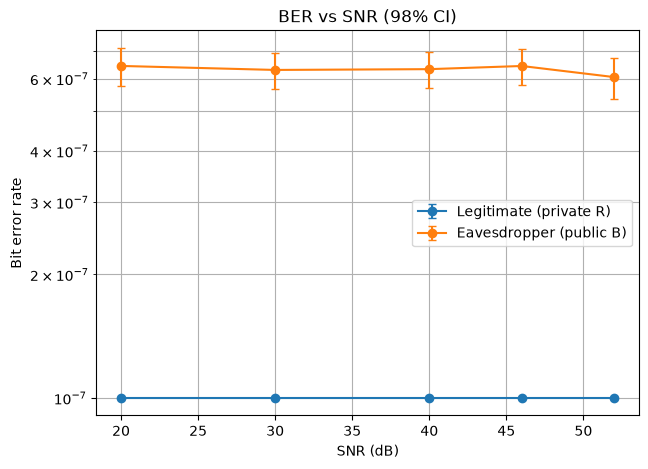

In [8]:
from ber import snr_sweep_ber, plot_ber_vs_snr

def run_once(ebno_db, seed=0, decryptor=None):
    """One independent Monte-Carlo trial -> BER. decryptor defaults to legit Babai."""
    torch.manual_seed(seed)
    decryptor = decryptor or encryptor.decrypt_w_babai

    bits = binary_source([batch_size, num_ofdm_symbols, fft_size, num_bits_per_symbol])
    symbols = mapper(bits)
    s_lat = symbols.squeeze(-1) * qam_lattice_scale.to(symbols.device)
    enc = encryptor.encrypt(s_lat)

    tx = ofdm_modulator(enc.to(torch.complex64))
    tx = channel_attenuation * tx
    no = sionna.phy.utils.ebnodb2no(ebno_db, num_bits_per_symbol, coderate=1)
    rx = awgn(tx, no)
    rx = receiver_amplifier(rx, gain_db=receiver_gain_db)
    rx_sym = ofdm_demodulator(rx) / (channel_attenuation * db_to_linear_amplitude(receiver_gain_db))

    dec = decryptor(rx_sym)
    dec = qam16_lattice_to_normalized(qam16_slicer_lattice(dec))
    rb = nearest_neighbor_qam_demapper(dec, mapper, num_bits_per_symbol)
    return bit_error_rate(bits, rb)

awgn = sionna.phy.channel.AWGN()
snr_list = [20, 30, 40, 46, 52]   # encrypted signal needs high SNR (paper Fig. 7)

legit = snr_sweep_ber(lambda s, seed: run_once(s, seed, encryptor.decrypt_w_babai), snr_list)
eve   = snr_sweep_ber(lambda s, seed: run_once(s, seed, encryptor.eavesdropper_babai), snr_list)
plot_ber_vs_snr({"Legitimate (private R)": legit, "Eavesdropper (public B)": eve})


## Point 4 — Lattice dimension > 350
The lattice dimension equals `fft_size` (number of OFDM sub-carriers). Abdallah Sec. 4.3 requires it to exceed 350 (>=400 to resist GGH/NTRU cryptanalysis). `fft_size=512` above satisfies this. To reproduce the paper's performance study, re-run the sweep for `fft_size in (128, 256, 512)`; note that only the >=400 settings are security-relevant.